# SASRec на Yandex Yambda: от item-эмбеддингов к semantic IDs

Реализация SASRec (Self-Attentive Sequential Recommendation, [Kang & McAuley, 2018](https://arxiv.org/abs/1808.09781)) с нуля на PyTorch, обученная на [Yandex Yambda](https://huggingface.co/datasets/yandex/yambda), открытом датасете Яндекс Музыки.

## Идея

SASRec это архитектура GPT, применённая не к тексту, а к последовательностям действий пользователей. Токен = трек вместо слова, «словарь» = каталог треков, задача = предсказать следующий элемент последовательности. Causal self-attention, positional embeddings, next-token prediction работают так же, как в языковой модели.

Self-attention реализован вручную, без `nn.MultiheadAttention`: цель проекта в том, чтобы разобраться в механике, а не собрать модель из готовых блоков.

## Что измеряется

Лесенка моделей возрастающей сложности, все на одном протоколе оценки:

| модель | представление трека |
|---|---|
| popularity, last-item | классические baseline'ы без обучения |
| SASRec на item-эмбеддингах | обучаемый вектор на каждый трек |
| SASRec на semantic IDs | 4 дискретных кода из аудио как последовательность токенов |
| SASRec на аудио-кодах | те же 4 кода как признаки трека, item-эмбеддингов нет |
| SASRec гибрид | item-эмбеддинги плюс аудио-коды |

**Semantic IDs** это токенизация треков: аудио-эмбеддинг квантуется через RQ-VAE в кортеж из нескольких кодов, словарь схлопывается со 181K айтемов до ~1000 токенов, и рекомендация превращается в авторегрессионную генерацию код-за-кодом (подход в духе [TIGER](https://arxiv.org/abs/2305.05065)).

Забегая вперёд: **как замена item-эмбеддингов semantic IDs проигрывают, а как дополнение к ним поднимают NDCG@10 на 39%.** Почему так, разбирается по ходу через per-position perplexity.

## Ограничения железа

Всё рассчитано на бесплатный Google Colab (T4, 16 GB, обрыв сессии каждые ~12 часов). Полный прогон занимает ~15 минут, из них ~5 минут это потоковое извлечение аудио-эмбеддингов из файла на 13.8 GB. Чекпойнты пишутся на Google Drive после каждой эпохи.

## 1. Setup

Проверяем GPU, ставим зависимости, монтируем Drive под чекпойнты.

In [69]:
import torch

print(f"torch: {torch.__version__}")
print(f"CUDA:  {torch.cuda.is_available()}")
print(f"GPU:   {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'нет'}")

torch: 2.11.0+cu128
CUDA:  True
GPU:   Tesla T4


Если GPU не определился, включите его: `Runtime -> Change runtime type -> T4 GPU`.

In [70]:
!pip install -q datasets

In [71]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/sasrec'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Артефакты проекта: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакты проекта: /content/drive/MyDrive/sasrec


Colab обрывает сессию каждые ~12 часов. Всё, что дорого пересчитывать, складывается на Drive: разбиение данных, извлечённые аудио-эмбеддинги, веса моделей, графики. После обрыва достаточно выполнить ячейки восстановления, а не пересчитывать всё заново.

Ниже два помощника для вывода, чтобы логи и таблицы во всём ноутбуке выглядели одинаково.

In [72]:
def kv(label, value):
    print(f"{label:<34}{value}")

def table(headers, rows):
    cols = list(zip(*([headers] + [[str(c) for c in r] for r in rows])))
    widths = [max(len(str(c)) for c in col) + 3 for col in cols]
    widths[0] = max(widths[0], 26)

    def line(row):
        return "".join(f"{str(c):<{widths[0]}}" if i == 0 else f"{str(c):>{widths[i]}}"
                       for i, c in enumerate(row))

    print(line(headers))
    print("-" * sum(widths))
    for r in rows:
        print(line(r))

In [120]:
RESET_CHECKPOINTS = False

if RESET_CHECKPOINTS:
    for f in ['sasrec_items.pt', 'sasrec_codes.pt', 'sasrec_codes_feat.pt',
              'sasrec_hybrid.pt', 'rqvae.pt']:
        p = f"{PROJECT_DIR}/{f}"
        if os.path.exists(p):
            os.remove(p)
            kv("удалён чекпойнт", f)
    print("сброс выполнен")

Сброс нужен, если RQ-VAE переобучался: размер словаря токенов зависит от того, как легли коллизии кодов, и старые веса окажутся несовместимы с новой схемой.

## 2. Данные

Yambda доступен в трёх размерах (50M / 500M / 5B событий) и в разбивке по типам взаимодействий. Берём `likes` из 50M-версии: 881K событий, ~8K пользователей, 181K треков.

Почему лайки, а не прослушивания: `listens` в этой версии содержит 46.5M событий, что для бесплатного Colab избыточно, а сам сигнал шумный (автоплей, фоновое прослушивание). Лайк это явное действие пользователя, поэтому последовательности чище.

Схема событий: `uid`, `item_id`, `timestamp`, `is_organic`. Все файлы отсортированы по `(uid, timestamp)`, то есть история каждого пользователя уже лежит в хронологическом порядке.

In [74]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from datasets import load_dataset
from datasets.utils.logging import disable_progress_bar
disable_progress_bar()

ds = load_dataset("yandex/yambda", data_dir="flat/50m", data_files="likes.parquet")
likes = ds["train"]

kv("колонки", list(likes.features))
kv("событий", f"{likes.num_rows:,}")

колонки                           ['uid', 'timestamp', 'item_id', 'is_organic']
событий                           881,456


In [75]:
import pandas as pd

df = likes.to_pandas()

kv("пользователей", f"{df['uid'].nunique():,}")
kv("уникальных треков", f"{df['item_id'].nunique():,}")
kv("всего событий", f"{len(df):,}")
kv("отсортировано по (uid, timestamp)",
   df.equals(df.sort_values(['uid', 'timestamp']).reset_index(drop=True)))

print()
hist_len = df.groupby('uid').size()
q = hist_len.describe(percentiles=[.5, .75, .9, .95, .99])
table(["длина истории", "значение"],
      [[k, f"{v:,.0f}"] for k, v in q.items() if k != 'count'])

пользователей                     8,283
уникальных треков                 181,304
всего событий                     881,456
отсортировано по (uid, timestamp) True

длина истории                значение
-------------------------------------
mean                              106
std                               209
min                                 1
50%                                44
75%                               124
90%                               270
95%                               398
99%                               847
max                             8,697


Три вещи из этого вывода определяют дальнейшие решения.

**Длина истории сильно разбросана**: медиана 44, 95-й перцентиль 398, максимум 8697. Отсюда `MAX_LEN = 100`, окно, покрывающее целиком примерно три четверти пользователей; у более активных берутся последние 100 треков. Внимание стоит `O(L^2)`, поэтому окно это прямой компромисс между полнотой истории и скоростью обучения.

**Есть пользователи с одним-двумя лайками.** При разбиении leave-last-out два последних элемента уходят в val и test, значит на обучение у них не остаётся ничего. Отфильтруем всех, у кого меньше 5 событий.

**Данные отсортированы по `(uid, timestamp)`**, поэтому последний трек пользователя это просто последняя строка его блока.

Про `timestamp`: это не абсолютное время, а дельты, разбитые на корзины по 5 секунд. Для нас важен только порядок.

## 3. Подготовка: маппинг и leave-last-out split

**Почему нельзя подавать `item_id` напрямую.** `nn.Embedding` это таблица, где строка `i` хранит вектор объекта с индексом `i`, и индексы обязаны идти подряд от нуля. Сырые `item_id` в Yambda это произвольные числа с дырами (встречаются и 7, и 8 миллионов), поэтому таблицу пришлось бы завести размером с максимальный id, где почти все строки пустые. Строим маппинг «встреченный `item_id` в подряд идущий индекс», а индекс 0 резервируем под PAD.

**Leave-last-out.** Задача предсказать *следующий* трек, поэтому разбиение делается по времени и отдельно для каждого пользователя. Из полной истории `[i1 ... iN]`:

- **test**: предсказать `iN`, вход `[i1 ... iN-1]`
- **val**: предсказать `iN-1`, вход `[i1 ... iN-2]`
- **train**: учимся на `[i1 ... iN-2]`, предсказывая каждый следующий элемент внутри

**Где здесь возможна утечка.** Тестовая цель `iN` не должна попадать ни в train, ни во вход val, и не попадает, потому что оба заканчиваются на `iN-2`. А вот val-цель `iN-1` во вход для test входить обязана: на момент предсказания `iN` этот трек реально был в прошлом пользователя. Это не утечка, а корректная история.

In [76]:
MIN_LEN = 5
MAX_LEN = 100
PAD_IDX = 0

before = df['uid'].nunique()
df = df[df.groupby('uid')['item_id'].transform('size') >= MIN_LEN].copy()

unique_items = df['item_id'].unique()
item2idx = {int(it): i for i, it in enumerate(unique_items, start=1)}
idx2item = {i: it for it, i in item2idx.items()}
n_items = len(item2idx)
vocab_size = n_items + 1
df['idx'] = df['item_id'].map(item2idx).astype('int64')

kv("пользователей было", f"{before:,}")
kv(f"осталось (>= {MIN_LEN} событий)", f"{df['uid'].nunique():,}")
kv("уникальных треков", f"{n_items:,}")
kv("размер словаря (с PAD)", f"{vocab_size:,}")

пользователей было                8,283
осталось (>= 5 событий)           6,951
уникальных треков                 180,942
размер словаря (с PAD)            180,943


In [77]:
df = df.sort_values(['uid', 'timestamp'])
user_seqs = df.groupby('uid')['idx'].apply(list)

train_seqs, val_data, test_data = {}, {}, {}

for uid, seq in user_seqs.items():
    train_seq = seq[:-2][-MAX_LEN:]
    train_seqs[uid] = train_seq
    val_data[uid] = (train_seq, seq[-2])
    test_data[uid] = (seq[:-1][-MAX_LEN:], seq[-1])

u = next(iter(train_seqs))
kv("пример: uid", u)
kv("train, последние 6 индексов", train_seqs[u][-6:])
kv("val: вход кончается на", f"{val_data[u][0][-1]}, цель {val_data[u][1]}")
kv("test: вход кончается на", f"{test_data[u][0][-1]}, цель {test_data[u][1]}")
kv("пользователей в разбиении", f"{len(train_seqs):,}")

пример: uid                       100
train, последние 6 индексов       [13, 14, 15, 16, 17, 18]
val: вход кончается на            18, цель 19
test: вход кончается на           19, цель 20
пользователей в разбиении         6,951


Проверка в выводе выше: последний элемент входа для test совпадает с целью val. Так и должно быть, val-трек на момент предсказания test-трека уже в прошлом пользователя. Обратное направление отсутствует по построению.

In [78]:
import pickle

with open(f"{PROJECT_DIR}/data_likes.pkl", 'wb') as f:
    pickle.dump({'item2idx': item2idx, 'idx2item': idx2item, 'vocab_size': vocab_size,
                 'MAX_LEN': MAX_LEN, 'PAD_IDX': PAD_IDX, 'train_seqs': train_seqs,
                 'val_data': val_data, 'test_data': test_data}, f)
kv("сохранено", f"{PROJECT_DIR}/data_likes.pkl")

сохранено                         /content/drive/MyDrive/sasrec/data_likes.pkl


Маппинг `item2idx` важно зафиксировать: `unique()` не гарантирует одинаковый порядок между запусками, и если пересобрать его заново, индексы поедут, а сохранённые веса станут ссылаться не на те треки.

Ячейка ниже это аварийный вход после обрыва Colab. В обычном прогоне она просто перезаписывает переменные теми же значениями.

In [79]:
import pickle

with open(f"{PROJECT_DIR}/data_likes.pkl", "rb") as f:
    a = pickle.load(f)

item2idx, idx2item = a['item2idx'], a['idx2item']
vocab_size, MAX_LEN, PAD_IDX = a['vocab_size'], a['MAX_LEN'], a['PAD_IDX']
train_seqs, val_data, test_data = a['train_seqs'], a['val_data'], a['test_data']
n_items = len(item2idx)

kv("восстановлено пользователей", f"{len(train_seqs):,}")
kv("восстановлено треков", f"{n_items:,}")

восстановлено пользователей       6,951
восстановлено треков              180,942


## 4. Протокол оценки и baseline'ы

Прежде чем обучать модели, нужны две вещи: способ измерять качество и точка отсчёта.

### Sampled evaluation

Честно было бы ранжировать настоящий следующий трек против всех 181K, но это медленно. Протокол из оригинальной статьи SASRec: берём 1 настоящий трек и 100 случайных негативов, ранжируем эти 101 кандидата и смотрим, на какое место попал настоящий.

### Метрики

- **HitRate@10**: попал ли настоящий трек в первую десятку, доля «да» по всем пользователям.
- **Recall@10**: при одном релевантном айтеме численно совпадает с HitRate@10.
- **NDCG@10**: учитывает не только попадание, но и позицию, вклад места `k` равен `1 / log2(k+1)`, то есть первое место даёт 1.0, десятое 0.29. Самая информативная из трёх.

### Обработка ничьих

Тонкий момент, на котором легко получить бессмысленный результат. Если считать ранг как «сколько кандидатов строго выше настоящего», то при равенстве скоров настоящий трек получает первое место даром. Для моделей с непрерывными скорами это неважно, но last-item baseline выдаёт всего два значения (0 или 1), и при таком подсчёте он показывал HitRate@10 = 1.0000, идеальный результат у заведомо примитивного метода.

Правильно делить ничью поровну: ранг = «строго выше» плюс половина от числа равных.

In [80]:
import numpy as np

N_NEG = 100
K = 10

def fair_rank(scores, target_idx=0):
    greater = int((scores > scores[target_idx]).sum())
    equal = int((scores == scores[target_idx]).sum())
    return greater + (equal - 1) / 2.0

In [81]:
from collections import Counter

pop = Counter()
for seq in train_seqs.values():
    pop.update(seq)
pop_rank = {it: r for r, (it, _) in enumerate(pop.most_common())}
MAX_R = len(pop_rank)

def eval_baselines(eval_data, seed=0):
    rng = np.random.default_rng(seed)
    out = {'popularity': [0.0, 0], 'last_item': [0.0, 0]}
    n = 0
    for uid, (inp_seq, target) in eval_data.items():
        cand = [target] + rng.integers(1, vocab_size, size=N_NEG).tolist()

        s = np.array([-pop_rank.get(c, MAX_R) for c in cand])
        r = fair_rank(s)
        if r < K:
            out['popularity'][0] += 1.0 / np.log2(r + 2)
            out['popularity'][1] += 1

        s = np.array([1 if c == inp_seq[-1] else 0 for c in cand])
        r = fair_rank(s)
        if r < K:
            out['last_item'][0] += 1.0 / np.log2(r + 2)
            out['last_item'][1] += 1
        n += 1
    return {k: {'NDCG@10': v[0] / n, 'HitRate@10': v[1] / n} for k, v in out.items()}

base = eval_baselines(test_data)

table(["baseline", "NDCG@10", "HitRate@10"],
      [[name, f"{base[name]['NDCG@10']:.4f}", f"{base[name]['HitRate@10']:.4f}"]
       for name in ['last_item', 'popularity']])

baseline                     NDCG@10   HitRate@10
-------------------------------------------------
last_item                     0.0145       0.0145
popularity                    0.4061       0.6179


**Popularity это сильный baseline, и так и должно быть.** На музыкальных лайках люди в основном отмечают то, что и так популярно, поэтому «советуй самое частое» работает неплохо. Любая последовательностная модель обязана его обыгрывать, иначе она не выучила ничего, кроме усреднённых вкусов.

**Last-item слабый**, на музыке люди редко лайкают подряд один и тот же трек. Именно на нём была поймана ошибка с ничьими: без честного деления он показывал HitRate@10 = 1.0. Общее правило: когда примитивный метод даёт идеальный результат, сломана метрика, а не метод.

Все последующие модели меряются этим же протоколом с тем же `seed`, то есть видят ровно те же 100 негативов на тех же пользователях.

## 5. Трансформер: causal self-attention с нуля

### Что делает self-attention

Для каждой позиции строится новое представление, вбирающее информацию из релевантных прошлых позиций. Из эмбеддинга каждой позиции тремя линейными слоями получаются:

- **Query**: что я ищу
- **Key**: о чём я
- **Value**: что я передам, если на меня обратят внимание

Релевантность пары позиций это скалярное произведение `q_i * k_j`, получается матрица `L x L`. После softmax по ключам она превращается в веса (положительные, в сумме 1), и выход позиции `i` это взвешенная сумма value-векторов.

**Деление на `sqrt(d_head)`.** Скалярное произведение растёт с размерностью: чем больше компонент складываем, тем шире разброс. Слишком большие скоры делают softmax чрезмерно уверенным, почти весь вес уходит в один элемент, градиенты по остальным зануляются, обучение застревает. Деление возвращает масштаб в разумные пределы.

### Две маски, которые легко перепутать

**Causal-маска** запрещает смотреть в будущее: позиция `t` видит только позиции `<= t`. Иначе модель увидит ответ. Маска треугольная и одинаковая для всех примеров в батче, зависит только от позиций.

**Padding-маска** запрещает внимать заполнителю у коротких историй. Она своя для каждого примера, зависит от содержимого.

Обе применяются до softmax через подстановку `-inf`: после экспоненты такие веса станут нулями.

### Ловушка с NaN

Если у примера вся последовательность это паддинг (в батче такое встречается), то у соответствующей строки запрещены все ключи. Softmax по сплошным `-inf` даёт `0/0 = NaN`, и одна такая строка через residual-связи отравляет весь батч. Лечится `torch.nan_to_num` после softmax: без этой строки обучение падает в NaN на первом же шаге.

In [82]:
import torch, torch.nn as nn, torch.nn.functional as F, math

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_len, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_head = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop, self.resid_drop = nn.Dropout(dropout), nn.Dropout(dropout)
        self.register_buffer('causal', torch.tril(torch.ones(max_len, max_len)).bool())

    def forward(self, x, pad_mask):
        B, L, _ = x.shape
        q, k, v = self.qkv(x).split(x.size(-1), dim=-1)
        q = q.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, L, self.n_heads, self.d_head).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = scores.masked_fill(~self.causal[:L, :L], float('-inf'))
        scores = scores.masked_fill(~pad_mask.view(B, 1, 1, L), float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)   # строки из сплошных -inf дают NaN
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).contiguous().view(B, L, -1)
        return self.resid_drop(self.proj(out))


class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_len, dropout):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_len, dropout)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(),
                                nn.Linear(d_ff, d_model), nn.Dropout(dropout))

    def forward(self, x, pad_mask):
        x = x + self.attn(self.ln1(x), pad_mask)
        x = x + self.ff(self.ln2(x))
        return x

## 6. Модель

Трансформер из предыдущей секции ничего не знает про треки, он принимает последовательность векторов и возвращает представления. Специфика задачи целиком в том, **как получается вектор трека**, и именно это мы будем менять по ходу проекта.

Класс ниже поддерживает три режима через флаги:

| режим | `use_items` | `use_codes` | вектор трека |
|---|---|---|---|
| item-эмбеддинги | да | | обучаемая строка таблицы |
| semantic-коды | | да | сумма эмбеддингов 4 аудио-кодов |
| гибрид | да | да | сумма обоих |

Аудио-коды появятся в секции 8; пока работает первый режим, а флаги нужны, чтобы позже сравнивать конфигурации одним и тем же кодом, без риска, что разница объясняется деталями реализации.

In [83]:
class SASRec(nn.Module):
    def __init__(self, vocab_size, max_len, code_table=None, code_sizes=None,
                 d_model=64, n_heads=2, n_blocks=2, d_ff=256, dropout=0.2,
                 pad_idx=0, use_items=True, use_codes=False):
        super().__init__()
        self.pad_idx, self.use_items, self.use_codes = pad_idx, use_items, use_codes
        assert use_items or use_codes

        if use_items:
            self.item_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        if use_codes:
            self.register_buffer('code_table', code_table)
            self.code_embs = nn.ModuleList([nn.Embedding(s, d_model) for s in code_sizes])

        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff, max_len, dropout)
                                     for _ in range(n_blocks)])
        self.ln_f = nn.LayerNorm(d_model)

        self.apply(self._init_weights)
        if use_items:
            with torch.no_grad():
                self.item_emb.weight[pad_idx].fill_(0)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def item_vec(self, idx):
        v = 0
        if self.use_items:
            v = v + self.item_emb(idx)
        if self.use_codes:
            codes = self.code_table[idx]
            for p, emb in enumerate(self.code_embs):
                v = v + emb(codes[..., p])
        return v

    def forward(self, seq):
        B, L = seq.shape
        pad_mask = (seq != self.pad_idx)
        pos = torch.arange(L, device=seq.device).unsqueeze(0)
        x = self.drop(self.item_vec(seq) + self.pos_emb(pos))
        for blk in self.blocks:
            x = blk(x, pad_mask)
        return self.ln_f(x)

Метод `item_vec` изолирует единственное место, которое различается между тремя конфигурациями, и используется везде, включая функцию потерь. Это делает ablation честным по построению.

### Данные для обучения

Как GPT предсказывает каждое следующее слово за один проход, так и здесь: из последовательности `[s1 ... sM]` делается пара «вход и цель со сдвигом на 1». Позиция, где стоит `s1`, предсказывает `s2`, и так далее, одна последовательность даёт `M-1` задач сразу.

Паддинг слева, реальные треки прижаты вправо: так предсказание на инференсе всегда снимается с последней позиции. Так же устроен и оригинальный SASRec.

### Функция потерь

Полный softmax по 181K айтемов не помещается в память T4: матрица логитов для батча 128 и окна 100 это `128 * 100 * 181000 * 4 байта`, около 9 GB на один тензор без учёта градиентов. Поэтому берём **negative sampling**: настоящий следующий трек плюс один случайный, и учим через BCE ставить первому высокий скор, второму низкий. За тысячи шагов с разными негативами это приближает ту же цель.

Скор трека это скалярное произведение `h_t * item_vec(j)`. Отдельного выходного слоя нет, для оценки переиспользуется то же представление, что на входе (weight tying).

In [84]:
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, user_seqs, max_len, pad_idx=0):
        self.seqs = list(user_seqs.values())
        self.max_len, self.pad_idx = max_len, pad_idx

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, i):
        s = self.seqs[i]
        inp = s[:-1][-self.max_len:]
        tgt = s[1:][-self.max_len:]
        pad = self.max_len - len(inp)   # одинаковый слева, чтобы inp[k] и tgt[k] совпадали
        return (torch.tensor([self.pad_idx] * pad + inp, dtype=torch.long),
                torch.tensor([self.pad_idx] * pad + tgt, dtype=torch.long))


def sasrec_loss(model, seq, tgt, vocab_size, pad_idx=0):
    h = model(seq)
    pos_v = model.item_vec(tgt)
    neg = torch.randint(1, vocab_size, tgt.shape, device=seq.device)
    neg_v = model.item_vec(neg)

    pos_logits = (h * pos_v).sum(-1)
    neg_logits = (h * neg_v).sum(-1)

    mask = (tgt != pad_idx).float()
    pl = F.binary_cross_entropy_with_logits(pos_logits, torch.ones_like(pos_logits),
                                            reduction='none')
    nl = F.binary_cross_entropy_with_logits(neg_logits, torch.zeros_like(neg_logits),
                                            reduction='none')
    return ((pl + nl) * mask).sum() / mask.sum()

### Проверка перед обучением

Приём из nanoGPT: посчитать, каким должен быть loss у необученной модели, и сверить с фактическим. Случайно инициализированные веса дают настоящему и случайному треку примерно одинаковый скор около нуля, `sigmoid(0) = 0.5`, штраф на каждом из двух членов `-ln(0.5) = ln 2`, в сумме `2 * ln 2`, около 1.386.

Если бы инициализация была неудачной (например, стандартный `std` вместо 0.02), скоры оказались бы далеко от нуля, sigmoid насытился бы, и loss стартовал бы с 5-10. Это сигнал искать ошибку до того, как потрачен час на обучение.

In [85]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)

_m = SASRec(vocab_size, MAX_LEN).to(device)
_dl = DataLoader(SeqDataset(train_seqs, MAX_LEN, PAD_IDX), batch_size=128, shuffle=True)
_inp, _tgt = next(iter(_dl))
_loss = sasrec_loss(_m, _inp.to(device), _tgt.to(device), vocab_size, PAD_IDX)

kv("параметров всего", f"{sum(p.numel() for p in _m.parameters()):,}")
kv("из них в item-эмбеддингах", f"{_m.item_emb.weight.numel():,}")
kv("начальный loss", f"{_loss.item():.4f}")
kv("ожидаемый loss", f"{2 * math.log(2):.4f}")

del _m, _dl

параметров всего                  11,686,848
из них в item-эмбеддингах         11,580,352
начальный loss                    1.3904
ожидаемый loss                    1.3863


### Обучение

Чекпойнт после каждой эпохи это не перестраховка, а необходимость: Colab обрывает сессию, и без сохранения обучение пришлось бы начинать заново. В чекпойнт идут не только веса, но и состояние оптимизатора: AdamW хранит бегущие средние градиентов, и продолжать с чистым оптимизатором значит получить рывок в обучении.

In [86]:
def save_ckpt(model, opt, epoch, path):
    torch.save({'model': model.state_dict(), 'optim': opt.state_dict(), 'epoch': epoch}, path)

def load_ckpt(model, opt, path):
    if not os.path.exists(path):
        return 0
    ck = torch.load(path, map_location=device)
    try:
        model.load_state_dict(ck['model'])
        opt.load_state_dict(ck['optim'])
    except RuntimeError:
        print("  чекпойнт несовместим с текущей конфигурацией, обучаем с нуля")
        return 0
    print(f"  загружен чекпойнт после эпохи {ck['epoch']}")
    return ck['epoch']


def train_model(tag, use_items=True, use_codes=False, code_table=None, code_sizes=None,
                epochs=20, batch_size=128, lr=1e-3, log_every=5):
    torch.manual_seed(0)
    model = SASRec(vocab_size, MAX_LEN, code_table, code_sizes,
                   use_items=use_items, use_codes=use_codes).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    ckpt = f"{PROJECT_DIR}/sasrec_{tag}.pt"
    start = load_ckpt(model, opt, ckpt)

    dl = DataLoader(SeqDataset(train_seqs, MAX_LEN, PAD_IDX),
                    batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    history = []

    for ep in range(start, epochs):
        model.train()
        running = 0.0
        for inp, tgt in dl:
            inp, tgt = inp.to(device), tgt.to(device)
            opt.zero_grad()
            loss = sasrec_loss(model, inp, tgt, vocab_size, PAD_IDX)
            loss.backward()
            opt.step()
            running += loss.item()

        avg = running / len(dl)
        history.append(avg)
        save_ckpt(model, opt, ep + 1, ckpt)
        if (ep + 1) % log_every == 0 or ep == 0:
            print(f"  эпоха {ep + 1:2d}/{epochs}   loss {avg:.4f}")

    return model, history

In [87]:
print("обучение: item-эмбеддинги")
m_items, hist_items = train_model("items", use_items=True, use_codes=False)

обучение: item-эмбеддинги
  эпоха  1/20   loss 1.2698
  эпоха  5/20   loss 0.8119
  эпоха 10/20   loss 0.5895
  эпоха 15/20   loss 0.4388
  эпоха 20/20   loss 0.3390


In [88]:
@torch.no_grad()
def evaluate(model, eval_data, seed=0):
    model.eval()
    rng = np.random.default_rng(seed)
    ndcg = hit = n = 0
    for uid, (inp_seq, target) in eval_data.items():
        seq = inp_seq[-MAX_LEN:]
        seq = [PAD_IDX] * (MAX_LEN - len(seq)) + seq
        h_last = model(torch.tensor([seq], device=device))[0, -1]

        cand = torch.tensor([target] + rng.integers(1, vocab_size, size=N_NEG).tolist(),
                            device=device)
        scores = model.item_vec(cand) @ h_last

        rank = fair_rank(scores)
        if rank < K:
            hit += 1
            ndcg += 1.0 / np.log2(rank + 2)
        n += 1
    return {'NDCG@10': ndcg / n, 'HitRate@10': hit / n}

In [89]:
results = {
    'last-item baseline': base['last_item'],
    'popularity baseline': base['popularity'],
}
results['item embeddings'] = evaluate(m_items, test_data)

table(["модель", "NDCG@10", "HitRate@10"],
      [[name, f"{m['NDCG@10']:.4f}", f"{m['HitRate@10']:.4f}"]
       for name, m in results.items()])

модель                       NDCG@10   HitRate@10
-------------------------------------------------
last-item baseline            0.0145       0.0145
popularity baseline           0.4061       0.6179
item embeddings               0.4130       0.6255


Модель на item-эмбеддингах обыгрывает popularity, значит она выучила именно последовательные паттерны, а не усреднённые вкусы. Отрыв скромный, и это ожидаемо: на музыкальных лайках популярность объясняет большую часть выбора.

Дальше попытка заменить обучаемые item-эмбеддинги на представление, выведенное из самого аудио.

## 7. Аудио-эмбеддинги: как достать нужное из файла на 13.8 GB

Yambda содержит `embeddings.parquet`, аудио-эмбеддинги 7.72M треков, полученные свёрточной сетью на спектрограммах. Файл весит 13.8 GB, скачивать его на Colab нельзя.

Нам нужны эмбеддинги только для 181K треков из нашей выборки, это около 2% файла. Parquet колоночный, и отсюда три рычага.

**Метаданные читаются отдельно от данных.** В конце файла лежит footer со схемой и статистикой, его можно получить одним HTTP-range-запросом, не качая тело. Разведка бесплатна.

**Колонки читаются независимо.** В файле три: `item_id`, `embed`, `normalized_embed`. Нам нужна одна из двух эмбеддинг-колонок, это сразу вдвое меньше трафика.

**Данные читаются батчами.** `iter_batches` тянет файл кусками, мы фильтруем на лету и держим в памяти только свои 181K векторов вместо 7.72M.

Итого вместо скачивания 13.8 GB получается потоковое чтение около 6 GB с сохранением ~93 MB на Drive. Один раз, дальше загрузка из кэша за секунды.

In [90]:
!pip install -q huggingface_hub pyarrow

from huggingface_hub import HfFileSystem
import pyarrow.parquet as pq

fs = HfFileSystem()
PATH = "datasets/yandex/yambda/embeddings.parquet"

pf = pq.ParquetFile(fs.open(PATH, "rb"))
md_pq = pf.metadata

kv("размер файла", f"{fs.info(PATH)['size'] / 1e9:.1f} GB")
kv("треков в файле", f"{md_pq.num_rows:,}")
kv("row groups", md_pq.num_row_groups)

print()
rg = md_pq.row_group(0)
table(["колонка", "объём по файлу"],
      [[rg.column(i).path_in_schema,
        f"{rg.column(i).total_compressed_size * md_pq.num_row_groups / 1e9:.1f} GB"]
       for i in range(rg.num_columns)])

batch = next(pf.iter_batches(batch_size=2, columns=['item_id', 'embed']))
EMB_DIM = len(batch.to_pylist()[0]['embed'])
print()
kv("размерность эмбеддинга", EMB_DIM)

размер файла                      13.8 GB
треков в файле                    7,721,749
row groups                        30

колонка                            объём по файлу
-------------------------------------------------
item_id                                    0.0 GB
embed.list.element                         6.0 GB
normalized_embed.list.element              8.1 GB

размерность эмбеддинга            128


Тип данных `double` (float64), при загрузке кастуем в float32: точность квантования от этого не пострадает, а памяти вдвое меньше.

Качаем колонку `embed`, а не `normalized_embed`: векторы те же, но нормированные значения хуже сжимаются и стоят на 2 GB больше. Нормализацию делаем сами одной строкой.

In [91]:
import numpy as np, time

need = np.array(sorted(item2idx.keys()), dtype=np.int64)
emb = np.zeros((vocab_size, EMB_DIM), dtype=np.float32)
found = np.zeros(vocab_size, dtype=bool)

t0, rows_seen = time.time(), 0
for batch in pf.iter_batches(batch_size=65536, columns=['item_id', 'embed']):
    ids = batch.column('item_id').to_numpy(zero_copy_only=False).astype(np.int64)
    hit = np.nonzero(np.isin(ids, need))[0]
    if len(hit):
        col = batch.column('embed')
        for j in hit:
            r = item2idx[int(ids[j])]
            emb[r] = col[int(j)].as_py()
            found[r] = True
    rows_seen += len(ids)
    if rows_seen % (65536 * 20) == 0:
        print(f"  {rows_seen:>10,} / {md_pq.num_rows:,}   найдено {found.sum():>7,}   "
              f"{(time.time() - t0) / 60:.1f} мин")

norms = np.linalg.norm(emb, axis=1, keepdims=True)
emb = np.divide(emb, norms, out=np.zeros_like(emb), where=norms > 0)

np.save(f"{PROJECT_DIR}/audio_emb.npy", emb)
np.save(f"{PROJECT_DIR}/audio_emb_found.npy", found)

print()
kv("время", f"{(time.time() - t0) / 60:.1f} мин")
kv("покрытие", f"{found[1:].sum():,} из {n_items:,} ({found[1:].mean() * 100:.1f}%)")
kv("сохранено на Drive", f"{emb.nbytes / 1e6:.0f} MB")

   1,310,720 / 7,721,749   найдено  28,856   0.6 мин
   2,621,440 / 7,721,749   найдено  57,925   1.1 мин
   3,932,160 / 7,721,749   найдено  86,974   1.7 мин
   5,242,880 / 7,721,749   найдено 115,819   2.3 мин
   6,553,600 / 7,721,749   найдено 144,716   2.8 мин

время                             3.2 мин
покрытие                          170,468 из 180,942 (94.2%)
сохранено на Drive                93 MB


In [92]:
emb = np.load(f"{PROJECT_DIR}/audio_emb.npy")
found = np.load(f"{PROJECT_DIR}/audio_emb_found.npy")
EMB_DIM = emb.shape[1]

kv("загружено эмбеддингов", f"{found[1:].sum():,}")
kv("размерность", EMB_DIM)

загружено эмбеддингов             170,468
размерность                       128


### Кто остался без эмбеддинга

Аудио есть не для всех треков каталога. Важно не количество пропусков само по себе, а их вес во взаимодействиях: если пропущенные треки лежат в длинном хвосте, потери минимальны; если среди них популярные, это ударит по качеству.

In [93]:
missing = np.nonzero(~found)[0]
missing = missing[missing != PAD_IDX]

cnt_missing = np.array([pop.get(int(i), 0) for i in missing])
cnt_all = np.array([pop.get(i, 0) for i in range(1, vocab_size)])
top100 = {it for it, _ in pop.most_common(100)}

kv("треков без эмбеддинга", f"{len(missing):,} ({len(missing) / n_items * 100:.1f}%)")
kv("медианная популярность", f"без аудио {np.median(cnt_missing):.0f}, по всем {np.median(cnt_all):.0f}")
kv("доля взаимодействий на них", f"{cnt_missing.sum() / cnt_all.sum() * 100:.1f}%")
kv("в топ-100 популярных", len(top100 & set(missing.tolist())))

треков без эмбеддинга             10,474 (5.8%)
медианная популярность            без аудио 1, по всем 1
доля взаимодействий на них        3.7%
в топ-100 популярных              1


Пропуски смещены в хвост: доля затронутых взаимодействий заметно меньше доли треков, а ядро каталога покрыто почти полностью. Значит эти треки можно обслужить отдельным спецкодом «аудио неизвестно», и модель выучит, что для них надо опираться только на поведенческий сигнал.

## 8. RQ-VAE: превращаем аудио в дискретные коды

Задача: заменить вектор из 128 чисел на кортеж маленьких целых, например `(142, 87, 231)`, так чтобы по кортежу вектор восстанавливался примерно как был.

### Зачем это нужно

Это **токенизация**. Было один атомарный id из словаря в 181K, стало последовательность токенов из словаря в несколько сотен. Ровно то же делает BPE с текстом: редкое слово разбивается на частые подслова, словарь схлопывается, а редкие объекты собираются из знакомых кусочков.

Два следствия:

- **Холодный старт решается сам.** Новый трек без истории прослушиваний всё равно получает осмысленные коды из своего звучания.
- **Выходной слой перестаёт быть проблемой.** Полный softmax по 1000 токенов считается мгновенно, а это то ограничение, из-за которого в секции 6 пришлось брать negative sampling.

### Как работает residual-квантование

**Один кодбук.** Таблица из `K` обучаемых векторов. Для входа ищем ближайший и записываем его номер. Но 256 вариантов на весь каталог это грубо.

**Остаточное квантование.** После первого шага считаем остаток `r1 = x - codebook1[код1]`, то, что первый кодбук не передал, и квантуем уже его вторым кодбуком. Потом остаток от остатка третьим. Восстановление это сумма трёх выбранных векторов.

Отсюда иерархия: первый код отвечает за грубое «в какой части пространства звучаний находится трек», следующие уточняют. Похожие треки совпадают по первому коду и расходятся по третьему. Комбинаторно 3 кодбука по 256 дают около 16.7M различимых комбинаций при словаре всего в 768 обучаемых векторов.

### Две технические детали

**Straight-through estimator.** Операция «взять ближайший вектор из таблицы» это argmin, у неё нет производной. Обходной приём: на forward используем квантованное значение, а на backward пропускаем градиент насквозь, будто квантования не было. В коде это `z_q = z + (z_q - z).detach()`, численно равно `z_q`, но градиент течёт в `z`.

**Мёртвые коды.** Типичная беда: часть векторов кодбука никогда не оказывается ближайшей ни к чему и перестаёт обучаться. Лечится инициализацией через k-means на реальных данных, кодбук сразу сажается в гущу распределения, а не в случайные точки.

### Конфигурация

Берём 3 уровня по 256 кодов, как в TIGER. Четвёртый уровень дал бы более точную реконструкцию, но удлинил бы последовательности, а внимание стоит `O(L^2)`.

In [94]:
class ResidualQuantizer(nn.Module):
    def __init__(self, n_levels=3, codebook_size=256, dim=32):
        super().__init__()
        self.n_levels, self.K = n_levels, codebook_size
        self.codebooks = nn.ModuleList([nn.Embedding(codebook_size, dim)
                                        for _ in range(n_levels)])
        for cb in self.codebooks:
            nn.init.normal_(cb.weight, std=0.02)
        self.register_buffer('usage', torch.zeros(n_levels, codebook_size))

    def forward(self, z):
        residual = z
        z_q_total = torch.zeros_like(z)
        codes, commit_loss = [], 0.0

        for lvl, cb in enumerate(self.codebooks):
            d = (residual.pow(2).sum(1, keepdim=True)
                 - 2 * residual @ cb.weight.t()
                 + cb.weight.pow(2).sum(1))
            idx = d.argmin(1)
            q = cb(idx)

            commit_loss = commit_loss + F.mse_loss(q, residual.detach()) \
                                      + 0.25 * F.mse_loss(residual, q.detach())

            q_st = residual + (q - residual).detach()   # straight-through
            z_q_total = z_q_total + q_st
            residual = residual - q

            codes.append(idx)
            if self.training:
                self.usage[lvl].scatter_add_(0, idx, torch.ones_like(idx, dtype=torch.float))

        return z_q_total, torch.stack(codes, 1), commit_loss


class RQVAE(nn.Module):
    def __init__(self, in_dim=128, hidden=256, latent=32, n_levels=3, K=256):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                     nn.Linear(hidden, latent))
        self.quantizer = ResidualQuantizer(n_levels, K, latent)
        self.decoder = nn.Sequential(nn.Linear(latent, hidden), nn.ReLU(),
                                     nn.Linear(hidden, in_dim))

    def forward(self, x):
        z = self.encoder(x)
        z_q, codes, commit = self.quantizer(z)
        return self.decoder(z_q), codes, commit

In [95]:
X = torch.tensor(emb[found], dtype=torch.float32)
idx_with_audio = np.nonzero(found)[0]

kv("обучающая выборка", tuple(X.shape))
kv("нормы векторов", f"min {X.norm(dim=1).min():.3f}, max {X.norm(dim=1).max():.3f}")

обучающая выборка                 (170468, 128)
нормы векторов                    min 1.000, max 1.000


In [96]:
from sklearn.cluster import MiniBatchKMeans

torch.manual_seed(0)
rqvae = RQVAE(in_dim=EMB_DIM).to(device)

with torch.no_grad():
    sample = X[torch.randperm(len(X))[:50000]].to(device)
    r = rqvae.encoder(sample)
    for lvl, cb in enumerate(rqvae.quantizer.codebooks):
        km = MiniBatchKMeans(n_clusters=256, n_init=3, random_state=0, batch_size=4096)
        km.fit(r.cpu().numpy())
        cb.weight.data = torch.tensor(km.cluster_centers_, dtype=torch.float32, device=device)
        r = r - cb(torch.tensor(km.predict(r.cpu().numpy()), device=device))
        kv(f"уровень {lvl + 1}, норма остатка", f"{r.norm(dim=1).mean():.4f}")

уровень 1, норма остатка          0.0579
уровень 2, норма остатка          0.0462
уровень 3, норма остатка          0.0390


Убывающая норма остатка подтверждает, что residual-схема работает: каждый следующий кодбук получает всё меньшую недосказанность.

In [97]:
from torch.utils.data import TensorDataset

with torch.no_grad():
    kv("||z|| до квантования", f"{rqvae.encoder(X[:20000].to(device)).norm(dim=1).mean():.4f}")

loader = DataLoader(TensorDataset(X), batch_size=1024, shuffle=True, drop_last=True)
opt_q = torch.optim.AdamW(rqvae.parameters(), lr=1e-3)

print()
for ep in range(30):
    rqvae.train()
    rqvae.quantizer.usage.zero_()
    tot_rec = tot_com = 0.0
    for (xb,) in loader:
        xb = xb.to(device)
        opt_q.zero_grad()
        xrec, _, commit = rqvae(xb)
        rec = F.mse_loss(xrec, xb)
        (rec + commit).backward()
        opt_q.step()
        tot_rec += rec.item()
        tot_com += commit.item()

    if (ep + 1) % 5 == 0 or ep == 0:
        alive = (rqvae.quantizer.usage > 0).float().mean(1) * 100
        print(f"  эпоха {ep + 1:2d}/30   rec {tot_rec / len(loader):.5f}   "
              f"commit {tot_com / len(loader):.5f}   "
              f"живых кодов {' '.join(f'{a:.0f}%' for a in alive)}")

torch.save(rqvae.state_dict(), f"{PROJECT_DIR}/rqvae.pt")

||z|| до квантования              0.2612

  эпоха  1/30   rec 0.00423   commit 0.00621   живых кодов 100% 100% 100%
  эпоха  5/30   rec 0.00142   commit 0.01231   живых кодов 57% 100% 100%
  эпоха 10/30   rec 0.00125   commit 0.01210   живых кодов 68% 100% 100%
  эпоха 15/30   rec 0.00119   commit 0.01187   живых кодов 76% 100% 100%
  эпоха 20/30   rec 0.00115   commit 0.01170   живых кодов 80% 100% 100%
  эпоха 25/30   rec 0.00113   commit 0.01155   живых кодов 85% 100% 100%
  эпоха 30/30   rec 0.00111   commit 0.01142   живых кодов 90% 100% 100%


Доля живых кодов первого уровня сначала падает, потом возвращается. Это не деградация, а пересборка: кодбуки инициализированы поверх ещё необученного энкодера, и как только энкодер начинает учиться, старая геометрия рассыпается. Дальше коды возвращаются в игру по мере того, как энкодер и квантователь подстраиваются друг под друга.

### Насколько хороши коды

Две вещи: сохраняют ли три числа информацию о звучании, и не оказываются ли разные треки неразличимыми.

In [98]:
rqvae.eval()
with torch.no_grad():
    Xd = X.to(device)
    xrec, codes, _ = rqvae(Xd)
    cos = F.cosine_similarity(xrec, Xd, dim=1)
    codes = codes.cpu().numpy()

cnt = Counter(map(tuple, codes))
collided = sum(v for v in cnt.values() if v > 1)
c1 = Counter(codes[:, 0])

kv("косинус восстановления", f"{cos.mean():.4f} (медиана {cos.median():.4f}, min {cos.min():.4f})")
kv("уникальных кортежей", f"{len(cnt):,} на {len(codes):,} треков")
kv("треков в коллизиях", f"{collided:,} ({collided / len(codes) * 100:.1f}%)")
kv("крупнейшая группа", f"{max(cnt.values())} треков с одним кодом")
kv("занято кодов 1-го уровня", f"{len(c1)}/256")
kv("крупнейший кластер", f"{max(c1.values()):,} треков ({max(c1.values()) / len(codes) * 100:.1f}%)")

косинус восстановления            0.9272 (медиана 0.9355, min 0.3389)
уникальных кортежей               139,118 на 170,468 треков
треков в коллизиях                48,534 (28.5%)
крупнейшая группа                 242 треков с одним кодом
занято кодов 1-го уровня          232/256
крупнейший кластер                1,753 треков (1.0%)


Косинус около 0.93 означает, что три числа сохраняют почти всю информацию о звучании, четвёртый уровень квантования не нужен. Распределение по первому коду ровное: крупнейший кластер занимает около процента каталога, то есть иерархия не выродилась.

**Но коллизий много.** Часть треков получила одинаковый кортеж и стала для модели неразличимой, она физически не сможет порекомендовать один из них, а не другой. Комбинаторно места хватало с запасом, но данные лежат в пространстве неравномерно.

Решение из TIGER: **четвёртый, разводящий код**. Внутри каждой группы коллизий трекам присваивается порядковый номер. Семантики он не несёт, это чистый разделитель.

In [99]:
from collections import defaultdict

N_CODES, CB = 4, 256
item_codes = np.full((vocab_size, N_CODES), -1, dtype=np.int64)

groups = defaultdict(int)
for row, tup in zip(idx_with_audio, map(tuple, codes)):
    item_codes[row, :3] = tup
    item_codes[row, 3] = groups[tup]
    groups[tup] += 1

no_audio = np.array([i for i in range(1, vocab_size) if not found[i]])
for k, row in enumerate(no_audio):
    item_codes[row] = [CB, k // (CB * CB), (k // CB) % CB, k % CB]

item_codes[PAD_IDX] = 0
real = item_codes[1:]
assert len({tuple(r) for r in real}) == len(real), "коллизии остались"

code_sizes = [int(real[:, p].max()) + 1 for p in range(N_CODES)]

kv("треков с аудио", f"{len(idx_with_audio):,}")
kv("разводящий код принимает", f"{item_codes[idx_with_audio, 3].max() + 1} значений")
kv("треков без аудио", f"{len(no_audio):,}, первый код {CB}")
kv("уникальность кодов", "все треки различимы")

print()
table(["позиция", "диапазон", "уникальных"],
      [[f"код {p + 1}", f"0..{code_sizes[p] - 1}", len(np.unique(real[:, p]))]
       for p in range(N_CODES)])

np.save(f"{PROJECT_DIR}/item_codes.npy", item_codes)
item_codes_t = torch.tensor(item_codes, dtype=torch.long, device=device)

треков с аудио                    170,468
разводящий код принимает          242 значений
треков без аудио                  10,474, первый код 256
уникальность кодов                все треки различимы

позиция                      диапазон   уникальных
--------------------------------------------------
код 1                          0..256          233
код 2                          0..255          256
код 3                          0..255          256
код 4                          0..255          256


Треки без аудио получают выделенный первый код 256, которого нет ни у одного трека с эмбеддингом. Модель сможет выучить, что этот код означает «звучание неизвестно», и опираться для таких треков только на поведенческий сигнал, по сути тот же обучаемый эмбеддинг, что раньше, но выраженный через ту же кодовую схему. Остальные три позиции для них это просто порядковый номер, разложенный по основанию 256, чтобы гарантировать уникальность.

### Осмысленны ли коды

Прежде чем строить проекцию, проверим структуру численно: на глаз тут легко обмануться.

In [100]:
import itertools

Xn = X.numpy()
top10 = [c for c, _ in Counter(codes[:, 0]).most_common(10)]
rng_v = np.random.default_rng(0)

rows = []
for c in top10:
    m = codes[:, 0] == c
    inside = Xn[m][:300]
    centroid = inside.mean(0)
    centroid /= np.linalg.norm(centroid)
    outside = Xn[~m][rng_v.choice((~m).sum(), 300, replace=False)]
    rows.append([f"код {c}", f"{m.sum():,}",
                 f"{(inside @ centroid).mean():.3f}",
                 f"{(outside @ centroid).mean():.3f}"])

table(["кластер", "треков", "косинус внутри", "косинус до чужих"], rows)

def centroid_of(c):
    v = Xn[codes[:, 0] == c].mean(0)
    return v / np.linalg.norm(v)

cent = {c: centroid_of(c) for c in top10}
pairs = sorted(((a, b, float(cent[a] @ cent[b]))
                for a, b in itertools.combinations(top10, 2)), key=lambda t: -t[2])

print()
kv("ближайшая пара кластеров", f"коды {pairs[0][0]} и {pairs[0][1]}, косинус {pairs[0][2]:.3f}")
kv("медиана по всем парам", f"{np.median([p[2] for p in pairs]):.3f}")

кластер                      треков   косинус внутри   косинус до чужих
-----------------------------------------------------------------------
код 150                       1,753            0.843              0.147
код 217                       1,606            0.868              0.142
код 38                        1,603            0.863              0.171
код 83                        1,509            0.887              0.142
код 185                       1,500            0.877              0.143
код 48                        1,490            0.809              0.103
код 12                        1,439            0.874              0.197
код 22                        1,432            0.839              0.150
код 90                        1,422            0.845              0.133
код 146                       1,419            0.877              0.176

ближайшая пара кластеров          коды 38 и 146, косинус 0.825
медиана по всем парам             0.096


In [101]:
import matplotlib.pyplot as plt, matplotlib as mpl

mpl.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 130, 'savefig.bbox': 'tight',
                     'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

FIG_DIR = f"{PROJECT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
C_MAIN, C_WEAK, C_BASE, C_DARK = '#2A7DE1', '#B0B7BF', '#E1852A', '#1B5AA8'

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


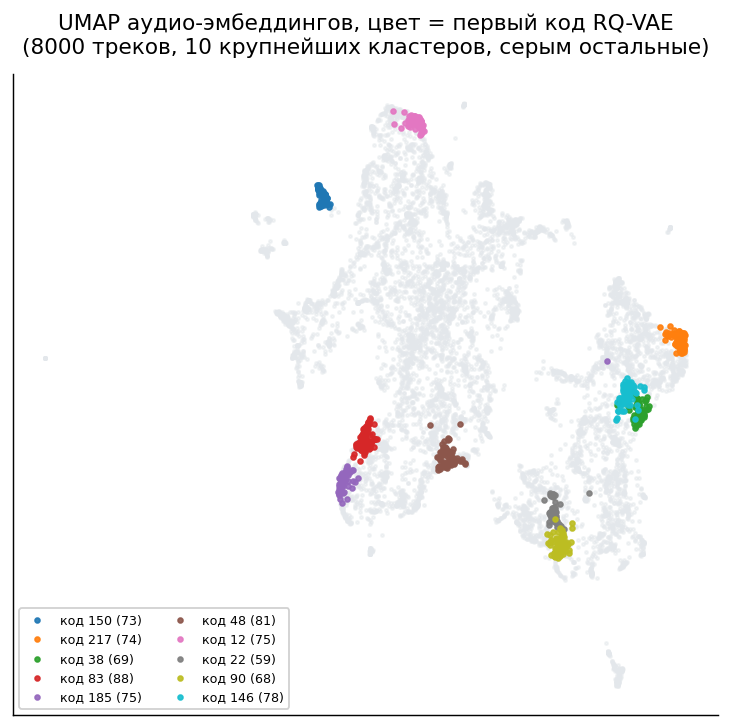

In [102]:
!pip install -q umap-learn
import umap

sub = rng_v.choice(len(X), size=8000, replace=False)
Xs, c1_sub = Xn[sub], codes[sub, 0]

emb2d = umap.UMAP(n_neighbors=30, min_dist=0.15, metric='cosine',
                  random_state=0).fit_transform(Xs)

fig, ax = plt.subplots(figsize=(7, 6.4))
other = ~np.isin(c1_sub, top10)
ax.scatter(emb2d[other, 0], emb2d[other, 1], s=3, c='#E3E7EB', alpha=0.45)
for j, c in enumerate(top10):
    m = c1_sub == c
    ax.scatter(emb2d[m, 0], emb2d[m, 1], s=7, color=plt.cm.tab10(j), alpha=0.9,
               label=f'код {c} ({m.sum()})')
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title('UMAP аудио-эмбеддингов, цвет = первый код RQ-VAE\n'
             '(8000 треков, 10 крупнейших кластеров, серым остальные)', pad=12)
ax.legend(fontsize=7, ncol=2, loc='lower left', framealpha=0.9)
plt.savefig(f'{FIG_DIR}/01_umap.png')
plt.show()

### Что показывает и чего не показывает этот график

Каждая точка это трек, положение задано аудио-эмбеддингом (128 измерений, сжатых до 2), цвет это первый код RQ-VAE. Серым показаны треки вне десятки крупнейших кластеров, около 95% выборки, поэтому серого много по построению.

**Кластеры плотные не только на картинке.** В исходном 128-мерном пространстве средний косинус внутри кластера около 0.81-0.89, до чужих треков 0.10-0.20. Разделение реальное, а не артефакт проекции.

**Перекрытия, где они есть, это иерархия, а не ошибка.** Первый уровень квантования нарезает непрерывное пространство звучаний, поэтому соседние области граничат: у самой близкой пары кодов косинус между центроидами заметно выше медианного по всем парам (см. вывод выше). Конкретные значения меняются от прогона к прогону вместе с тем, как сложились кластеры.

**Чего график не доказывает.** Он показывает качество *токенизации*, а не качество *рекомендаций*. Коды осмысленно кодируют звучание, но, как выяснится в следующей секции, модель на одних кодах проигрывает модели на item-эмбеддингах. Причина не в плохих кодах, а в том, что нижние уровни квантования непредсказуемы из истории прослушиваний.

Про проекцию: t-SNE с евклидовой метрикой на этих данных рвал кластеры на части, потому что векторы нормированы и лежат на сфере, а правильная мера близости здесь угловая. UMAP с `metric='cosine'` даёт цельную картину.

## 9. Модель на semantic IDs: генеративный подход

Теперь заменим item-эмбеддинги полностью. Трек больше не атомарный объект, он последовательность из 4 токенов, и модель предсказывает их авторегрессионно, код за кодом. Это подход **generative retrieval**: рекомендация становится генерацией, а не ранжированием.

### Раздельные диапазоны словаря

Код 5 на первом уровне (грубая семантика) и код 5 на четвёртом (разводящий счётчик) это разные сущности. Если дать им один токен, модель будет вынуждена различать их по контексту. Дешевле развести сразу: каждая позиция занимает свой кусок словаря.

### Длина последовательности

4 токена на трек означают, что окно в 100 треков это 400 токенов. Внимание стоит `O(L^2)`, то есть вчетверо дороже, чем раньше при том же числе треков. Окно оставляем прежним, чтобы сравнение с предыдущей моделью оставалось честным: разница должна объясняться представлением, а не длиной контекста.

### Полный softmax

Словарь схлопывается со 181K айтемов до ~1000 токенов, и это главный технический выигрыш токенизации. Negative sampling больше не нужен, считаем обычную cross-entropy.

In [103]:
MAX_ITEMS = MAX_LEN
MAX_TOK = MAX_ITEMS * N_CODES
PAD_TOK = 0

offset = np.cumsum([1] + code_sizes[:-1])
TOK_VOCAB = 1 + sum(code_sizes)

item2tok = np.zeros((vocab_size, N_CODES), dtype=np.int64)
for p in range(N_CODES):
    item2tok[1:, p] = item_codes[1:, p] + offset[p]
item2tok[PAD_IDX] = PAD_TOK

kv("размер кодбука по позициям", code_sizes)
kv("смещения в словаре", offset.tolist())
kv("словарь токенов", f"{TOK_VOCAB:,} (было айтемов {vocab_size:,})")
kv("сжатие словаря", f"в {vocab_size / TOK_VOCAB:.0f} раз")
kv("пример: трек idx=1", item2tok[1].tolist())

размер кодбука по позициям        [257, 256, 256, 256]
смещения в словаре                [1, 258, 514, 770]
словарь токенов                   1,026 (было айтемов 180,943)
сжатие словаря                    в 176 раз
пример: трек idx=1                [191, 500, 737, 770]


In [104]:
tok2item = {tuple(item2tok[i]): i for i in range(1, vocab_size)}

prefix_ok = defaultdict(set)
for i in range(1, vocab_size):
    t = tuple(item2tok[i])
    for p in range(N_CODES):
        prefix_ok[t[:p]].add(t[p])

kv("обратная таблица", f"{len(tok2item):,} записей")
kv("узлов в префиксном дереве", f"{len(prefix_ok):,}")
kv("ветвлений на 1-й позиции", len(prefix_ok[()]))

обратная таблица                  180,942 записей
узлов в префиксном дереве         174,681
ветвлений на 1-й позиции          233


Префиксное дерево понадобится при генерации в секции 10: словарь допускает любую комбинацию токенов, но реальным трекам соответствует лишь малая часть путей.

In [105]:
class CodeSeqDataset(Dataset):
    def __init__(self, user_seqs, item2tok, max_items, n_codes, pad_tok=0):
        self.seqs = list(user_seqs.values())
        self.item2tok, self.max_items = item2tok, max_items
        self.n_codes, self.pad_tok = n_codes, pad_tok
        self.max_tok = max_items * n_codes

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, i):
        s = self.seqs[i][-(self.max_items + 1):]
        toks = self.item2tok[s].reshape(-1)

        inp = toks[:-self.n_codes][-self.max_tok:]
        tgt = toks[self.n_codes:][-self.max_tok:]   # сдвиг на целый трек, не на токен

        pad = self.max_tok - len(inp)
        return (torch.from_numpy(np.concatenate([np.full(pad, self.pad_tok), inp])),
                torch.from_numpy(np.concatenate([np.full(pad, self.pad_tok), tgt])))

Сдвиг на 4 токена, а не на 1, это принципиальный момент. Мы предсказываем следующий *трек*, поэтому на позиции первого кода трека N целью должен быть первый код трека N+1. Сдвиг на один токен превратил бы задачу в «предсказать следующий код того же трека», она заметно легче, и метрики стали бы несравнимы с предыдущей моделью.

In [106]:
class SASRecCodes(nn.Module):
    def __init__(self, tok_vocab, max_tok, n_codes=4, d_model=64, n_heads=2,
                 n_blocks=2, d_ff=256, dropout=0.2, pad_tok=0):
        super().__init__()
        self.pad_tok, self.n_codes = pad_tok, n_codes
        self.tok_emb = nn.Embedding(tok_vocab, d_model, padding_idx=pad_tok)
        self.pos_emb = nn.Embedding(max_tok, d_model)
        self.code_emb = nn.Embedding(n_codes, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff, max_tok, dropout)
                                     for _ in range(n_blocks)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, tok_vocab)

        self.apply(self._init_weights)
        with torch.no_grad():
            self.tok_emb.weight[pad_tok].fill_(0)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, seq):
        B, L = seq.shape
        pad_mask = (seq != self.pad_tok)
        pos = torch.arange(L, device=seq.device).unsqueeze(0)
        code = pos % self.n_codes
        x = self.drop(self.tok_emb(seq) + self.pos_emb(pos) + self.code_emb(code))
        for blk in self.blocks:
            x = blk(x, pad_mask)
        return self.head(self.ln_f(x))

Третье слагаемое на входе это `code_emb`, оно сообщает модели, какой это код внутри трека: грубый семантический, уточняющий или разводящий счётчик. Вычисляется как `pos % 4`, и именно поэтому паддинг обязан быть кратен четырём, иначе выравнивание поедет.

In [107]:
train_loader_v2 = DataLoader(CodeSeqDataset(train_seqs, item2tok, MAX_ITEMS, N_CODES, PAD_TOK),
                             batch_size=128, shuffle=True, num_workers=2, drop_last=True)

torch.manual_seed(0)
model_codes = SASRecCodes(TOK_VOCAB, MAX_TOK).to(device)

inp, tgt = next(iter(train_loader_v2))
logits = model_codes(inp.to(device))
loss0 = F.cross_entropy(logits.reshape(-1, TOK_VOCAB), tgt.to(device).reshape(-1),
                        ignore_index=PAD_TOK)

kv("параметров", f"{sum(p.numel() for p in model_codes.parameters()):,}")
kv("форма выхода", tuple(logits.shape))
kv("начальный loss", f"{loss0.item():.4f}")
kv("ожидаемый loss", f"{math.log(TOK_VOCAB):.4f}")

параметров                        258,306
форма выхода                      (128, 400, 1026)
начальный loss                    6.9373
ожидаемый loss                    6.9334


Модель стала легче почти в 45 раз. Раньше из ~11.7M параметров 11.6M сидели в таблице item-эмбеддингов, то есть модель почти целиком состояла из запоминания отдельных треков. Здесь эта таблица схлопнулась примерно до 66K, и основную массу составляет сам трансформер. Знание о треках переехало из параметров в структуру кодов.

Ожидаемый начальный loss считается иначе, чем в секции 6: там был BCE с одним негативом, здесь полный softmax по `TOK_VOCAB` классам, поэтому необученная модель даёт `ln(TOK_VOCAB)`.

In [108]:
CKPT_CODES = f"{PROJECT_DIR}/sasrec_codes.pt"

torch.manual_seed(0)
model_codes = SASRecCodes(TOK_VOCAB, MAX_TOK).to(device)
opt_c = torch.optim.AdamW(model_codes.parameters(), lr=1e-3, weight_decay=0.01)
start_ep = load_ckpt(model_codes, opt_c, CKPT_CODES)

hist_codes_gen = []
for ep in range(start_ep, 30):
    model_codes.train()
    running = 0.0
    for inp, tgt in train_loader_v2:
        inp, tgt = inp.to(device), tgt.to(device)
        opt_c.zero_grad()
        loss = F.cross_entropy(model_codes(inp).reshape(-1, TOK_VOCAB), tgt.reshape(-1),
                               ignore_index=PAD_TOK)
        loss.backward()
        opt_c.step()
        running += loss.item()

    avg = running / len(train_loader_v2)
    hist_codes_gen.append(avg)
    save_ckpt(model_codes, opt_c, ep + 1, CKPT_CODES)
    if (ep + 1) % 5 == 0 or ep == 0:
        print(f"  эпоха {ep + 1:2d}/30   loss {avg:.4f}   perplexity {math.exp(avg):.1f}")

  эпоха  1/30   loss 5.5667   perplexity 261.6
  эпоха  5/30   loss 3.9659   perplexity 52.8
  эпоха 10/30   loss 3.8529   perplexity 47.1
  эпоха 15/30   loss 3.8218   perplexity 45.7
  эпоха 20/30   loss 3.8078   perplexity 45.1
  эпоха 25/30   loss 3.7970   perplexity 44.6
  эпоха 30/30   loss 3.7882   perplexity 44.2


Perplexity это `exp(loss)`, интерпретируется наглядно: сколько вариантов модель реально рассматривает на каждом шаге. Стартует с размера словаря и падает по мере обучения.

### Почему модель проиграла

Прежде чем делать выводы, надо понять, где именно теряется качество, иначе непонятно, чинить токенизацию или менять способ её использования. Два измерения: насколько предсказуем каждый уровень квантования, и сколько каждый из них добавляет к качеству ранжирования.

In [109]:
model_codes.eval()
pos_loss = torch.zeros(N_CODES, device=device)
pos_cnt = torch.zeros(N_CODES, device=device)
code_pos = torch.arange(MAX_TOK, device=device) % N_CODES

with torch.no_grad():
    for inp, tgt in train_loader_v2:
        inp, tgt = inp.to(device), tgt.to(device)
        l = F.cross_entropy(model_codes(inp).reshape(-1, TOK_VOCAB), tgt.reshape(-1),
                            ignore_index=PAD_TOK, reduction='none').view(tgt.shape)
        mask = (tgt != PAD_TOK).float()
        for p in range(N_CODES):
            sel = (code_pos == p).float().unsqueeze(0) * mask
            pos_loss[p] += (l * sel).sum()
            pos_cnt[p] += sel.sum()

ppl_by_pos = [math.exp((pos_loss[p] / pos_cnt[p]).item()) for p in range(N_CODES)]

labels = ["код 1 (грубая семантика)", "код 2 (уточнение)",
          "код 3 (уточнение)", "код 4 (разводящий)"]
table(["позиция", "perplexity", "размер кодбука"],
      [[labels[p], f"{ppl_by_pos[p]:.1f}", code_sizes[p]] for p in range(N_CODES)])

позиция                       perplexity   размер кодбука
---------------------------------------------------------
код 1 (грубая семантика)            49.7              257
код 2 (уточнение)                  152.2              256
код 3 (уточнение)                  201.3              256
код 4 (разводящий)                   2.2              256


In [110]:
@torch.no_grad()
def evaluate_codes(model, eval_data, seed=0):
    model.eval()
    rng = np.random.default_rng(seed)
    hist_cap = MAX_TOK - N_CODES
    ndcg = np.zeros(N_CODES)
    hit = np.zeros(N_CODES)
    n = 0

    for uid, (inp_seq, target) in eval_data.items():
        ht = item2tok[inp_seq[-(MAX_ITEMS - 1):]].reshape(-1).astype(np.int64)
        ht = np.concatenate([np.zeros(hist_cap - len(ht), dtype=np.int64), ht])

        cand = np.concatenate([[target], rng.integers(1, vocab_size, size=N_NEG)])
        ct = item2tok[cand]

        seqs = np.tile(ht, (len(cand), 1))
        seqs = np.concatenate([seqs, ct[:, :3], np.zeros((len(cand), 1), dtype=np.int64)], axis=1)

        logp = F.log_softmax(model(torch.from_numpy(seqs).long().to(device))[:, -5:-1], dim=-1)
        per_code = logp.gather(2, torch.from_numpy(ct).to(device).unsqueeze(2)).squeeze(2)
        cum = per_code.cumsum(1)   # скор по первым 1, 2, 3, 4 кодам сразу

        for p in range(N_CODES):
            r = fair_rank(cum[:, p])
            if r < K:
                hit[p] += 1
                ndcg[p] += 1.0 / np.log2(r + 2)
        n += 1
        if n % 2000 == 0:
            print(f"  {n:,}/{len(eval_data):,}")

    return [{'NDCG@10': ndcg[p] / n, 'HitRate@10': hit[p] / n} for p in range(N_CODES)]

In [111]:
levels = evaluate_codes(model_codes, test_data)

print()
table(["кодов учтено в скоре", "NDCG@10", "HitRate@10"],
      [[f"первые {p}", f"{m['NDCG@10']:.4f}", f"{m['HitRate@10']:.4f}"]
       for p, m in enumerate(levels, 1)])

ndcg_by_level = [m['NDCG@10'] for m in levels]
results['semantic IDs (замена)'] = levels[-1]

  2,000/6,951
  4,000/6,951
  6,000/6,951

кодов учтено в скоре         NDCG@10   HitRate@10
-------------------------------------------------
первые 1                      0.0802       0.2060
первые 2                      0.0955       0.2228
первые 3                      0.1279       0.2643
первые 4                      0.1809       0.3371


**Первый уровень выучен, нижние почти нет.** Perplexity первого кода в несколько раз ниже размера кодбука, второго и третьего близка к нему, то есть модель угадывает их почти случайно.

Причина фундаментальная: **RQ-VAE обучался на реконструкцию аудио, а не на предсказуемость из истории**. Первый уровень несёт грубую семантику вроде «что-то электронное, быстрое», и она выводится из поведения: слушал электронику, дальше вероятна электроника. Нижние уровни кодируют мелкие акустические детали остатка, которых в истории прослушиваний нет в принципе. Мы оптимизировали токенизацию под одну задачу, а используем в другой.

**Но коды не бесполезны.** Каждый следующий уровень монотонно улучшает ранжирование, включая разводящий. Значит проблема не в том, что коды шумят, а в том, что их суммарной различающей силы не хватает, чтобы заменить 11.6M параметров item-эмбеддингов.

Отсюда гипотеза для секции 11: использовать коды не вместо, а вместе с ними.

## 10. Constrained beam search: генерация вместо ранжирования

До сих пор модель оценивала готовых кандидатов. Но постановка с кодами позволяет большее: **генерировать** трек с нуля, код за кодом, как языковая модель порождает текст.

Проблема в том, что словарь допускает любую комбинацию из ~1000 токенов, а реальным трекам соответствует лишь малая часть путей. Наивная генерация почти всегда упиралась бы в несуществующий трек.

Решение это **constrained decoding**: на каждом шаге разрешены только те токены, которые продолжают реальный трек. Для этого и строилось префиксное дерево `prefix_ok`.

In [112]:
@torch.no_grad()
def beam_search(model, hist_items, beam_width=10, n_return=10):
    model.eval()
    hist_cap = MAX_TOK - N_CODES
    ht = item2tok[hist_items[-(MAX_ITEMS - 1):]].reshape(-1).astype(np.int64)
    ht = np.concatenate([np.zeros(hist_cap - len(ht), dtype=np.int64), ht])

    beams = [([], 0.0)]

    for step in range(N_CODES):
        seqs = np.stack([
            np.concatenate([ht,
                            np.array(prefix, dtype=np.int64),
                            np.zeros(N_CODES - len(prefix), dtype=np.int64)])
            for prefix, _ in beams
        ])
        logp = F.log_softmax(
            model(torch.from_numpy(seqs).long().to(device))[:, hist_cap + step], dim=-1)

        cands = []
        for b, (prefix, score) in enumerate(beams):
            allowed = prefix_ok.get(tuple(prefix), set())
            if not allowed:
                continue
            allowed = torch.tensor(sorted(allowed), device=device, dtype=torch.long)
            top_lp, top_i = logp[b, allowed].topk(min(beam_width, len(allowed)))
            for v, ti in zip(top_lp.tolist(), top_i.tolist()):
                cands.append((prefix + [int(allowed[ti])], score + v))

        cands.sort(key=lambda x: -x[1])
        beams = cands[:beam_width]

    return [(tok2item[tuple(p)], s) for p, s in beams[:n_return] if tuple(p) in tok2item]

In [113]:
import random

uid = random.choice([u for u, (inp, _) in test_data.items() if len(inp) >= 10])
hist, true_next = test_data[uid]

kv("пользователь", uid)
kv("история", f"{len(hist)} треков, модель видит последние {min(len(hist), MAX_ITEMS - 1)}")
kv("последние 5 прослушанных", [idx2item[i] for i in hist[-5:]])

print()
gen = beam_search(model_codes, hist, beam_width=20, n_return=5)
table(["ранг", "трек", "log P"],
      [[f"{r}", idx2item[it], f"{sc:+.2f}"] for r, (it, sc) in enumerate(gen, 1)])

print()
kv("реально следующим был", idx2item[true_next])
kv("попал в выдачу", true_next in [it for it, _ in gen])

пользователь                      258800
история                           100 треков, модель видит последние 99
последние 5 прослушанных          [7823803, 5116369, 1184356, 5334516, 1545568]

ранг                            трек    log P
---------------------------------------------
1                            1028059   -11.58
2                            8260662   -11.61
3                            8746667   -11.69
4                            9294744   -11.81
5                            5188835   -11.85

реально следующим был             2207459
попал в выдачу                    False


Все сгенерированные треки существуют в каталоге, значит constrained decoding работает. Попадание в настоящий трек здесь редкость, и это ожидаемо: модель генерирует из 181K без подсказок, что несопоставимо сложнее, чем выбрать из 101 кандидата. Демонстрация показывает, что генеративный механизм работает, а не что он лучший рекомендатель.

## 11. Гибрид: коды как дополнение к item-эмбеддингам

Диагностика показала, что коды несут полезный сигнал, но его недостаточно, чтобы заменить обучаемые item-эмбеддинги. Логичный ход это использовать оба источника вместе.

Класс `SASRec` из секции 6 это уже умеет: `item_vec` складывает обучаемый вектор трека и эмбеддинги его четырёх кодов. Меняются только флаги, всё остальное (архитектура, loss, процедура обучения, протокол оценки) идентично.

Конфигурация на кодах отличается от модели из секции 9 принципиально: там коды были последовательностью токенов с авторегрессионным предсказанием, здесь они признаки трека, который остаётся одной позицией. Одни и те же коды, два разных способа их использовать.

In [114]:
print("обучение: audio codes как фичи")
m_codes_feat, hist_codes = train_model("codes_feat", use_items=False, use_codes=True,
                                       code_table=item_codes_t, code_sizes=code_sizes)

print()
print("обучение: гибрид")
m_hybrid, hist_hybrid = train_model("hybrid", use_items=True, use_codes=True,
                                    code_table=item_codes_t, code_sizes=code_sizes)

обучение: audio codes как фичи
  эпоха  1/20   loss 1.1765
  эпоха  5/20   loss 0.8307
  эпоха 10/20   loss 0.7986
  эпоха 15/20   loss 0.7844
  эпоха 20/20   loss 0.7750

обучение: гибрид
  эпоха  1/20   loss 1.1284
  эпоха  5/20   loss 0.4710
  эпоха 10/20   loss 0.3126
  эпоха 15/20   loss 0.2369
  эпоха 20/20   loss 0.1932


In [115]:
results['audio codes (фичи)'] = evaluate(m_codes_feat, test_data)
results['hybrid'] = evaluate(m_hybrid, test_data)

order = ['last-item baseline', 'popularity baseline', 'semantic IDs (замена)',
         'audio codes (фичи)', 'item embeddings', 'hybrid']

table(["модель", "NDCG@10", "HitRate@10"],
      [[name, f"{results[name]['NDCG@10']:.4f}", f"{results[name]['HitRate@10']:.4f}"]
       for name in order])

gain = (results['hybrid']['NDCG@10'] / results['item embeddings']['NDCG@10'] - 1) * 100
print()
kv("вклад кодов поверх item-эмбеддингов", f" {gain:+.1f}% к NDCG@10")

модель                       NDCG@10   HitRate@10
-------------------------------------------------
last-item baseline            0.0145       0.0145
popularity baseline           0.4061       0.6179
semantic IDs (замена)         0.1809       0.3371
audio codes (фичи)            0.4024       0.6621
item embeddings               0.4130       0.6255
hybrid                        0.5750       0.7911

вклад кодов поверх item-эмбеддингов +39.2% к NDCG@10


### Не переобучение ли это

Гибрид имеет больше параметров, чем обе изолированные конфигурации, поэтому прирост нужно перепроверить на отложенной выборке. Смотрим на близость метрик val и test у каждой модели и, главное, на то, сохраняется ли прирост гибрида на val.

In [116]:
res_val = {tag: evaluate(m, val_data) for tag, m in
           [('item embeddings', m_items), ('audio codes (фичи)', m_codes_feat),
            ('hybrid', m_hybrid)]}

table(["модель", "NDCG test", "NDCG val", "разница"],
      [[tag, f"{results[tag]['NDCG@10']:.4f}", f"{res_val[tag]['NDCG@10']:.4f}",
        f"{res_val[tag]['NDCG@10'] - results[tag]['NDCG@10']:+.4f}"]
       for tag in ['item embeddings', 'audio codes (фичи)', 'hybrid']])

g_test = (results['hybrid']['NDCG@10'] / results['item embeddings']['NDCG@10'] - 1) * 100
g_val = (res_val['hybrid']['NDCG@10'] / res_val['item embeddings']['NDCG@10'] - 1) * 100
print()
kv("прирост гибрида на test", f"{g_test:+.1f}%")
kv("прирост гибрида на val", f"{g_val:+.1f}%")

модель                       NDCG test   NDCG val   разница
-----------------------------------------------------------
item embeddings                 0.4130     0.4258   +0.0129
audio codes (фичи)              0.4024     0.4193   +0.0170
hybrid                          0.5750     0.5969   +0.0219

прирост гибрида на test           +39.2%
прирост гибрида на val            +40.2%


Все конфигурации показывают одинаковый паттерн: val немного выше test, знак один и тот же, величина небольшая. Это систематический сдвиг, а не переобучение, потому что val-цель стоит ближе к концу обучающей истории и предсказывается чуть легче.

Прирост гибрида сохраняется на обеих выборках. Если бы модель подогналась под тест, на val он был бы заметно меньше.

Ещё одна закономерность: разрыв между val и test растёт с числом параметров, минимальный у конфигурации на кодах, максимальный у гибрида. Модели ведут себя предсказуемо.

## 12. Итоги

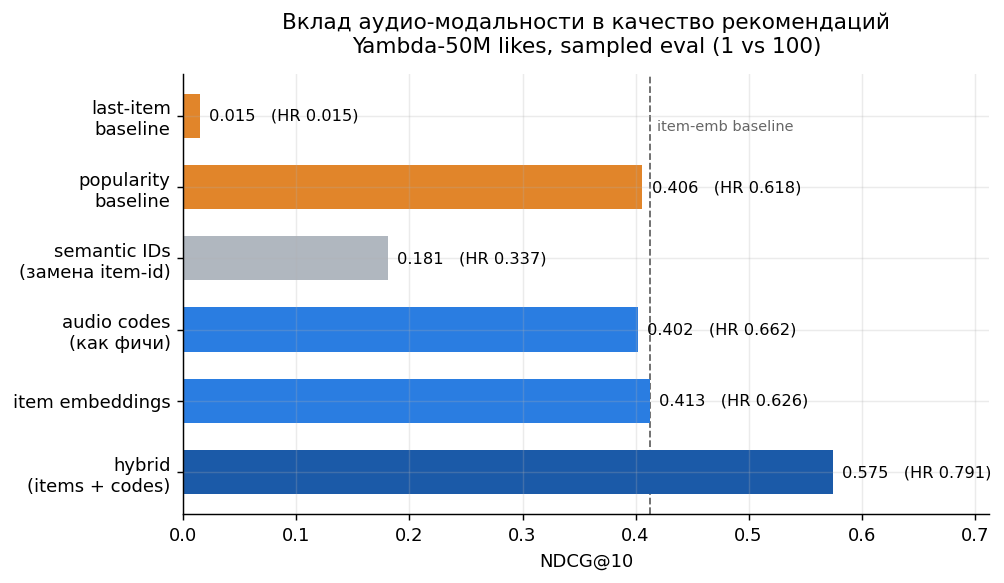

In [124]:
labels_ru = ['last-item\nbaseline', 'popularity\nbaseline', 'semantic IDs\n(замена item-id)',
             'audio codes\n(как фичи)', 'item embeddings', 'hybrid\n(items + codes)']
nd = [results[k]['NDCG@10'] for k in order]
hr = [results[k]['HitRate@10'] for k in order]
colors = [C_BASE, C_BASE, C_WEAK, C_MAIN, C_MAIN, C_DARK]

fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(order))
ax.barh(y, nd, color=colors, height=0.62)
ax.set_yticks(y); ax.set_yticklabels(labels_ru); ax.invert_yaxis()
ax.set_xlabel('NDCG@10'); ax.set_xlim(0, max(nd) * 1.24)
ax.set_title('Вклад аудио-модальности в качество рекомендаций\n'
             'Yambda-50M likes, sampled eval (1 vs 100)', pad=12)
for i, (v, h) in enumerate(zip(nd, hr)):
    ax.text(v + 0.008, i, f'{v:.3f}   (HR {h:.3f})', va='center', fontsize=9)

base_x = results['item embeddings']['NDCG@10']
ax.axvline(base_x, ls='--', lw=1, color='#666', zorder=0)
ax.text(base_x + 0.006, 0.15, 'item-emb baseline', fontsize=8, color='#666',
        ha='left', va='center', rotation=0)
plt.savefig(f'{FIG_DIR}/02_ablation.png')
plt.show()

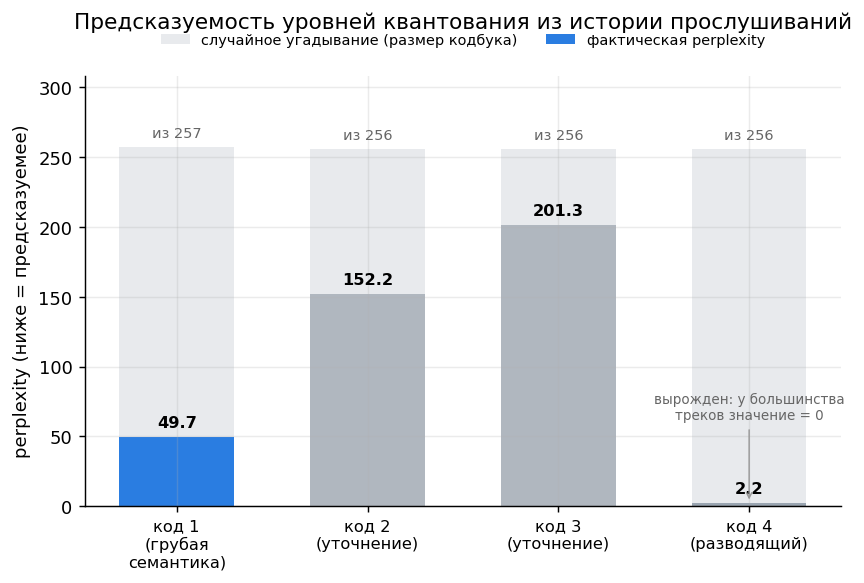

In [118]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
x = np.arange(N_CODES)
ax.bar(x, code_sizes, width=0.6, color='#E8EAED', label='случайное угадывание (размер кодбука)')
ax.bar(x, ppl_by_pos, width=0.6, color=[C_MAIN, C_WEAK, C_WEAK, '#9AA5B1'],
       label='фактическая perplexity')
ax.set_xticks(x)
ax.set_xticklabels(['код 1\n(грубая\nсемантика)', 'код 2\n(уточнение)',
                    'код 3\n(уточнение)', 'код 4\n(разводящий)'], fontsize=9)
ax.set_ylabel('perplexity (ниже = предсказуемее)')
ax.set_title('Предсказуемость уровней квантования из истории прослушиваний', pad=26)
for i, (p, c) in enumerate(zip(ppl_by_pos, code_sizes)):
    ax.text(i, p + 7, f'{p:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i, c + 7, f'из {c}', ha='center', fontsize=8, color='#666')
ax.set_ylim(0, max(code_sizes) * 1.2)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=2, framealpha=0)
ax.annotate('вырожден: у большинства\nтреков значение = 0', xy=(3, ppl_by_pos[3]),
            xytext=(3, 62), fontsize=7.5, color='#666', ha='center',
            arrowprops=dict(arrowstyle='->', color='#999', lw=0.8))
plt.savefig(f'{FIG_DIR}/03_perplexity.png')
plt.show()

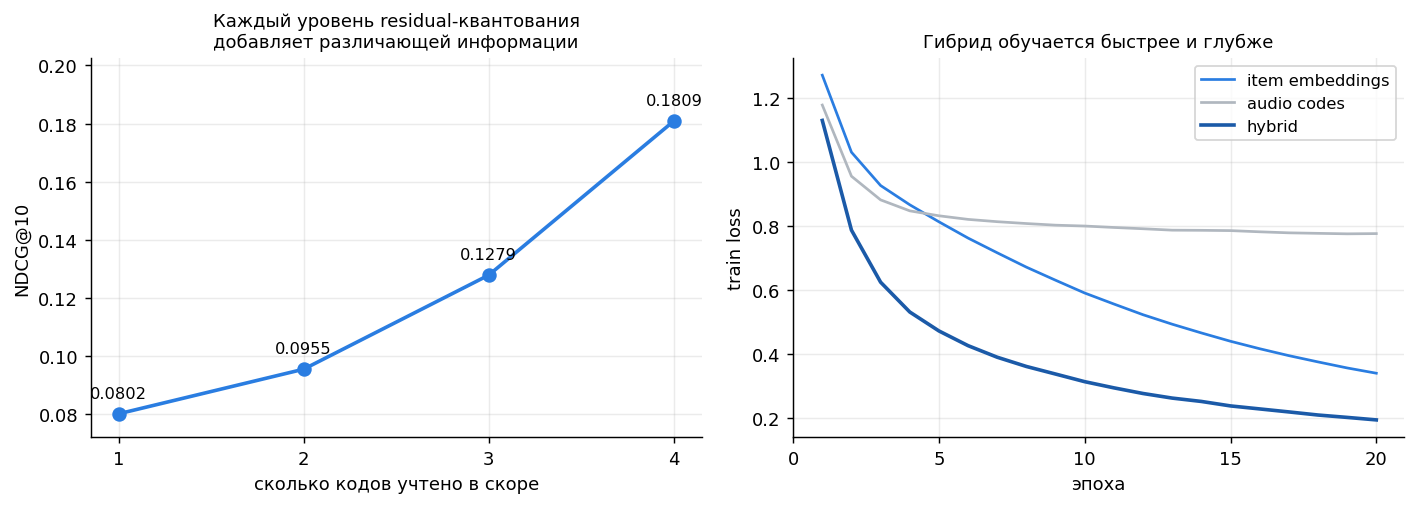

In [121]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

lv = list(range(1, N_CODES + 1))
ax1.plot(lv, ndcg_by_level, 'o-', color=C_MAIN, lw=2, ms=7)
for a, b in zip(lv, ndcg_by_level):
    ax1.annotate(f'{b:.4f}', (a, b), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9)
ax1.set_xticks(lv)
ax1.set_xlabel('сколько кодов учтено в скоре')
ax1.set_ylabel('NDCG@10')
ax1.set_ylim(min(ndcg_by_level) * 0.9, max(ndcg_by_level) * 1.12)
ax1.set_title('Каждый уровень residual-квантования\nдобавляет различающей информации',
              fontsize=10)

ax2.plot(range(1, len(hist_items) + 1), hist_items, label='item embeddings', color=C_MAIN)
ax2.plot(range(1, len(hist_codes) + 1), hist_codes, label='audio codes', color=C_WEAK)
ax2.plot(range(1, len(hist_hybrid) + 1), hist_hybrid, label='hybrid', color=C_DARK, lw=2)
ax2.set_xlabel('эпоха')
ax2.set_ylabel('train loss')
ax2.set_title('Гибрид обучается быстрее и глубже', fontsize=10)
ax2.set_xticks(range(0, len(hist_items) + 1, 5))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_levels_and_training.png')
plt.show()

### Что получилось

**Гибрид это лучшая конфигурация.** Item-эмбеддинги и аудио-коды несут разную информацию: первые помнят индивидуальное поведение трека, вторые знают, как он звучит. Вместе они дают заметно больше, чем каждый по отдельности.

**Semantic IDs как замена item-id не работают, но не потому, что коды плохие.** Диагностика показала конкретную причину: первый уровень квантования предсказуем из истории прослушиваний, нижние почти нет. RQ-VAE оптимизировался на реконструкцию аудио, а рекомендательной модели нужна предсказуемость из поведения. Это разные цели, и токенизация, хорошая для первой, оказывается недостаточной для второй.

**Коды как фичи сопоставимы с item-эмбеддингами** при несоизмеримо меньшем числе параметров: четыре небольшие таблицы вместо 11.6M обучаемых векторов. При этом у них выше HitRate, но ниже NDCG, то есть семантика хорошо сужает круг похожего, но хуже различает внутри него.

Любопытная деталь: по NDCG конфигурация на кодах чуть уступает даже popularity-baseline (0.4024 против 0.4061), зато по HitRate уверенно его обходит (0.6621 против 0.6179). Аудио-семантика хорошо затаскивает нужный трек в топ-10, но плохо ставит его на первое место.

### Что осознанно не сделано

- **Обучение на `listens`.** 46.5M событий вместо 881K это другой масштаб, но и другое время обучения. Проект ограничен бесплатным Colab.
- **RQ-VAE, обученный на предсказуемость.** Логичное продолжение: квантовать не под реконструкцию аудио, а совместно с рекомендательной моделью. Это исследовательская работа, а не инженерная правка.
- **Метаданные треков.** `artist_id` и `album_id` доступны в Yambda и почти наверняка добавили бы сигнала, особенно для треков без аудио.
- **Более одного негатива на позицию**, LR-scheduler, тюнинг гиперпараметров: качество можно поднять и без архитектурных изменений.

### Оговорки к результатам

- **Sampled evaluation оптимистичен.** Ранжирование против 100 негативов проще, чем против полного каталога в 181K. Числа сопоставимы между моделями, но не с абсолютными метриками из статей на других протоколах.
- **Негативы не исключают историю пользователя.** В протоколе оригинальной статьи негативы сэмплируются из треков, с которыми пользователь не взаимодействовал, здесь равномерно по каталогу. Смещение небольшое и работает против моделей, то есть метрики скорее занижены.
- **Кодовая схема зависит от состояния глобального RNG.** При прогоне сверху вниз результат воспроизводим: два независимых прогона дали одинаковые коды и метрики. Но если переобучить RQ-VAE после других операций с генератором, коллизии лягут иначе и размер словаря токенов сдвинется.
- **Один прогон, один seed.** Доверительных интервалов нет, различия в третьем знаке не следует считать значимыми.

### Ссылки

- Kang & McAuley (2018), Self-Attentive Sequential Recommendation: [arXiv:1808.09781](https://arxiv.org/abs/1808.09781)
- Rajput et al. (2023), Recommender Systems with Generative Retrieval (TIGER): [arXiv:2305.05065](https://arxiv.org/abs/2305.05065)
- Yandex Yambda: [huggingface.co/datasets/yandex/yambda](https://huggingface.co/datasets/yandex/yambda)
- Andrej Karpathy, nanoGPT: [github.com/karpathy/nanoGPT](https://github.com/karpathy/nanoGPT)
- Andrej Karpathy, Let's build GPT: from scratch, in code, spelled out: [YouTube](https://www.youtube.com/watch?v=kCc8FmEb1nY)